In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\\kirut\Downloads\cardio_train (1).csv",sep=";")
df["age"]=(df["age"]/365).astype(int)
df.drop("id",axis=1,inplace=True)
print(df.head())

   age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  \
0   50       2     168    62.0    110     80            1     1      0     0   
1   55       1     156    85.0    140     90            3     1      0     0   
2   51       1     165    64.0    130     70            3     1      0     0   
3   48       2     169    82.0    150    100            1     1      0     0   
4   47       1     156    56.0    100     60            1     1      0     0   

   active  cardio  
0       1       0  
1       1       1  
2       0       1  
3       1       1  
4       0       0  


In [2]:
# Dataset Information
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(70000, 12)

Column Names:
Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB

Missing Values:
age            0

In [4]:
# Data Preprocessing

# Convert age from days to years
df["age"] = (df["age"] / 365).astype(int)

# Remove 'id' column only if it exists
if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

# Display first 5 rows
print("First 5 Rows After Preprocessing:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

First 5 Rows After Preprocessing:
   age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  \
0    0       2     168    62.0    110     80            1     1      0     0   
1    0       1     156    85.0    140     90            3     1      0     0   
2    0       1     165    64.0    130     70            3     1      0     0   
3    0       2     169    82.0    150    100            1     1      0     0   
4    0       1     156    56.0    100     60            1     1      0     0   

   active  cardio  
0       1       0  
1       1       1  
2       0       1  
3       1       1  
4       0       0  

Dataset Shape:
(70000, 12)


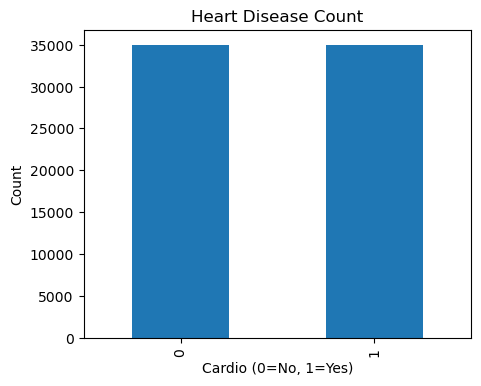

In [5]:
import matplotlib.pyplot as plt

# Heart Disease Count
plt.figure(figsize=(5,4))
df["cardio"].value_counts().plot(kind="bar")
plt.title("Heart Disease Count")
plt.xlabel("Cardio (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

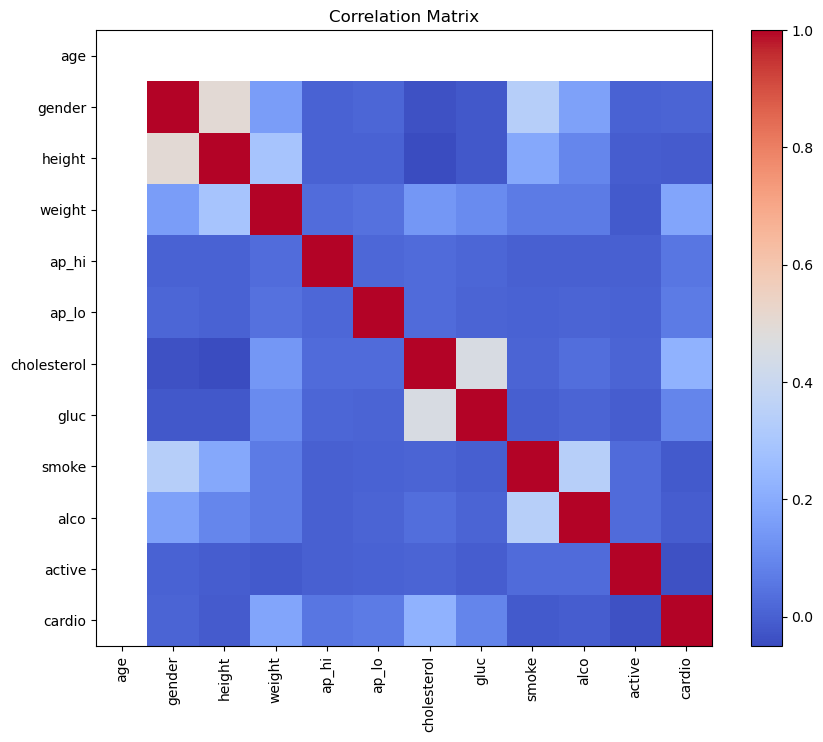

In [6]:
import matplotlib.pyplot as plt

# Correlation Matrix
corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and Target
X = df.drop("cardio", axis=1)
y = df["cardio"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6415

Confusion Matrix:
[[4976 2012]
 [3007 4005]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.71      0.66      6988
           1       0.67      0.57      0.61      7012

    accuracy                           0.64     14000
   macro avg       0.64      0.64      0.64     14000
weighted avg       0.64      0.64      0.64     14000



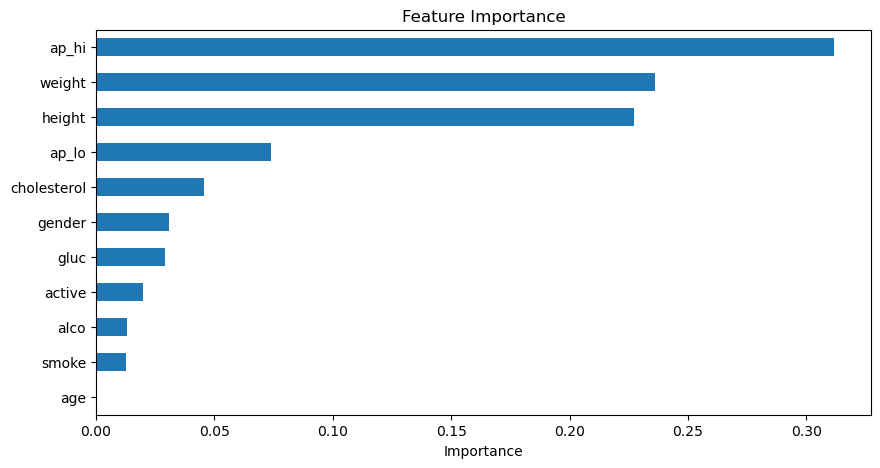

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

importance = model.feature_importances_
features = X.columns

feature_importance = pd.Series(importance, index=features)

plt.figure(figsize=(10,5))
feature_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [9]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Heart Disease Predicted")
else:
    print("No Heart Disease Predicted")

No Heart Disease Predicted
